# Notebook

### 1 - Library loading

In [1]:
from src.data_processing import load_data
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import math
import seaborn as sns

### 2 - Load Data

In [2]:
df =load_data("CMAPSSData/train_FD001.txt")
df.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


### 3 - Exploratory Data Analysis

#### a) Variance table, high and low variance sensors

We first analyse the variance of all the sensors, some have 0 or near 0 variance, we categorize them under low_variance_features. The others with higher variance are ccategorized under high_variance_features.

In [3]:
# Variance table for all sensors
variance_table = df[df.columns[5:26]]
variance_table = variance_table.var()
variance_table = variance_table.to_frame(name='Variance')
variance_table = variance_table.round(5)
print(variance_table)

# list of features with variance less than 0.01
low_variance_features = variance_table[variance_table['Variance'] == 0].index.tolist()
print(f"Features with low variance: {low_variance_features}")

# list of features with variance greater than 0.01
high_variance_features = variance_table[variance_table['Variance'] != 0].index.tolist()
print(f"Features with high variance: {high_variance_features}")

      Variance
s1     0.00000
s2     0.25005
s3    37.59099
s4    81.01089
s5     0.00000
s6     0.00000
s7     0.78339
s8     0.00504
s9   487.65357
s10    0.00000
s11    0.07134
s12    0.54399
s13    0.00517
s14  363.90049
s15    0.00141
s16    0.00000
s17    2.39867
s18    0.00000
s19    0.00000
s20    0.03267
s21    0.01172
Features with low variance: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Features with high variance: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


#### b) Sensors against engine cycles

First we start by plotting the high_variance_features over the engine cycles. We can observe that all sensors with high variances seem informative about the engines cycles.

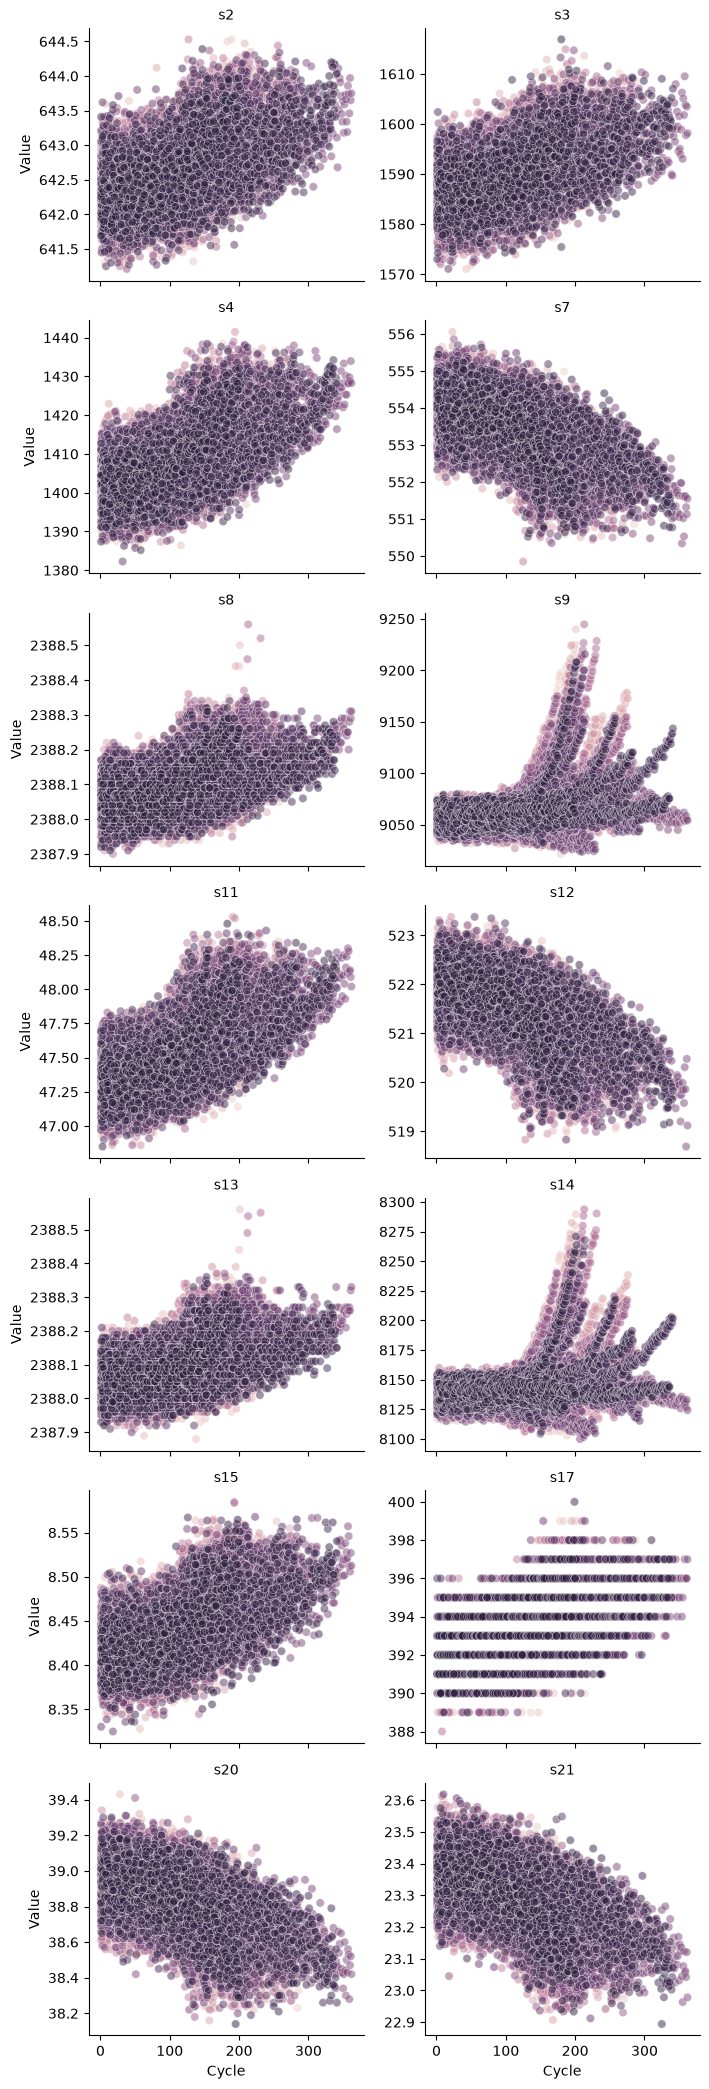

In [5]:
long_df = df.melt(
    id_vars=["cycle", "unit"],
    value_vars=high_variance_features,
    var_name="sensor",
    value_name="value"
)

g = sns.FacetGrid(
    long_df,
    col="sensor",
    col_wrap=2,
    height=3,
    aspect=1.2,
    sharey=False 
)

g.map_dataframe(
    sns.scatterplot,
    x="cycle",
    y="value",
    hue="unit",
    alpha=0.5,
    legend=False
)

g.set_axis_labels("Cycle", "Value")
g.set_titles("{col_name}")

plt.show()

Now we plot the low_variance_features over the engine cycles. We can observe that all sensors with low variances are not informative about the engines cycles, we then decide to remove them from any of our analysis.

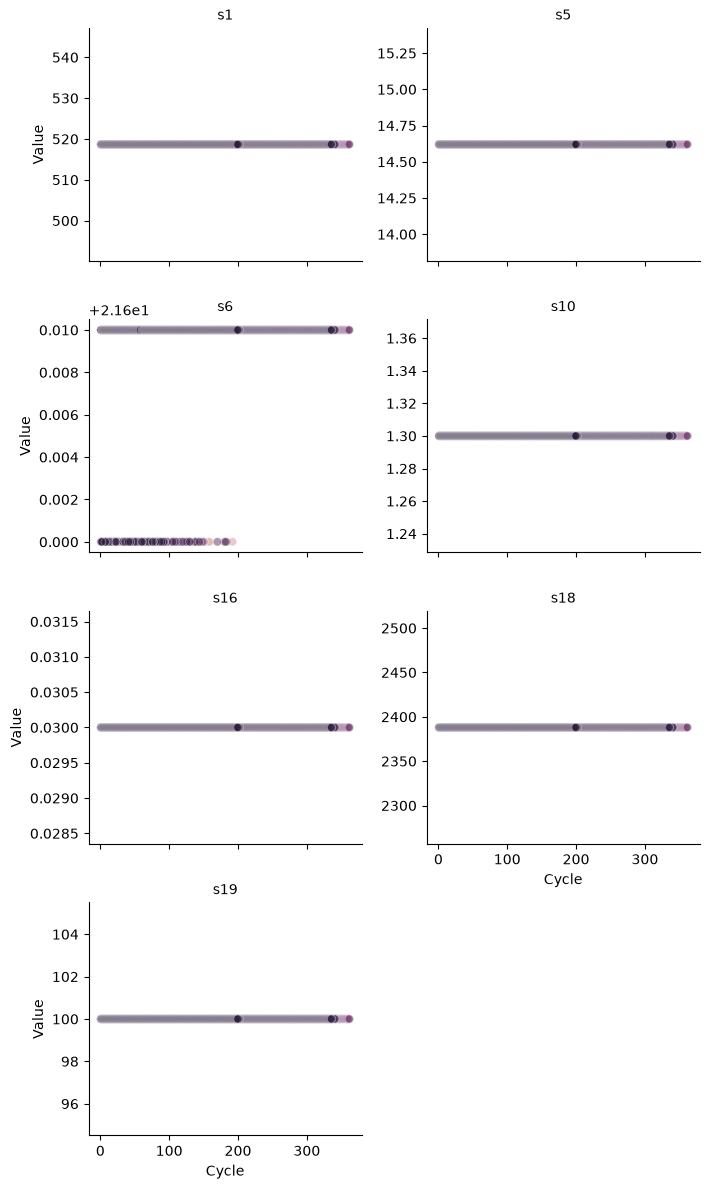

In [4]:
long_df = df.melt(
    id_vars=["cycle", "unit"],
    value_vars=low_variance_features,
    var_name="sensor",
    value_name="value"
)

g = sns.FacetGrid(
    long_df,
    col="sensor",
    col_wrap=2,
    height=3,
    aspect=1.2,
    sharey=False 
)

g.map_dataframe(
    sns.scatterplot,
    x="cycle",
    y="value",
    hue="unit",
    alpha=0.5,
    legend=False
)

g.set_axis_labels("Cycle", "Value")
g.set_titles("{col_name}")

plt.show()

#### c) Distribution of max RUL per engine

The dataset is ballanced since the plot follows what looks like a gaussian distribution.

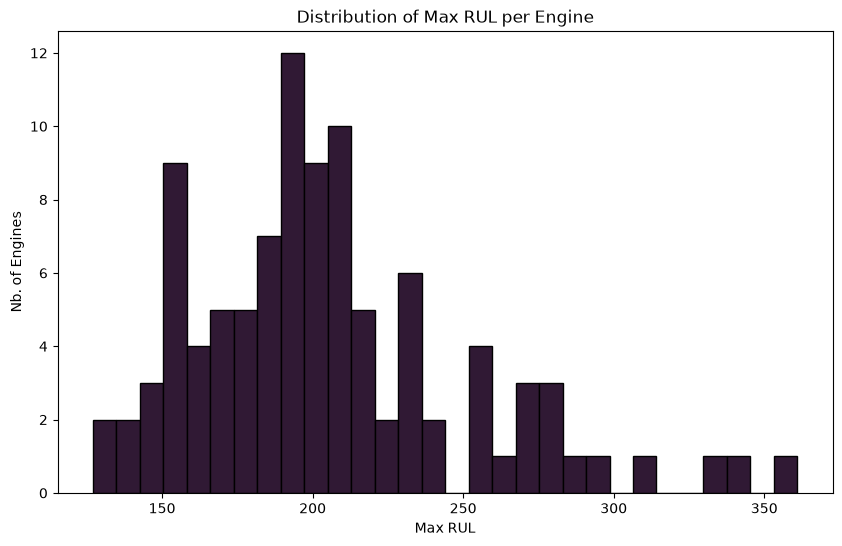

In [11]:
# Add the variable max_rul_per_engine to store the maximum RUL for each unit
max_rul = df.groupby("unit")["RUL"].max()

# Plot the distribution of max RUL per engine
plt.figure(figsize=(10, 6))
plt.hist(max_rul, bins=30, edgecolor='black', color='#301934')
plt.xlabel('Max RUL')
plt.ylabel('Nb. of Engines')
plt.title('Distribution of Max RUL per Engine')
plt.show()

#### d) Heatmap of sensor correlations

We detect some Multicolinearity, the data seems highly redundant, some variable. We have a massive cluster of sensors that are heavily correlated with each other.

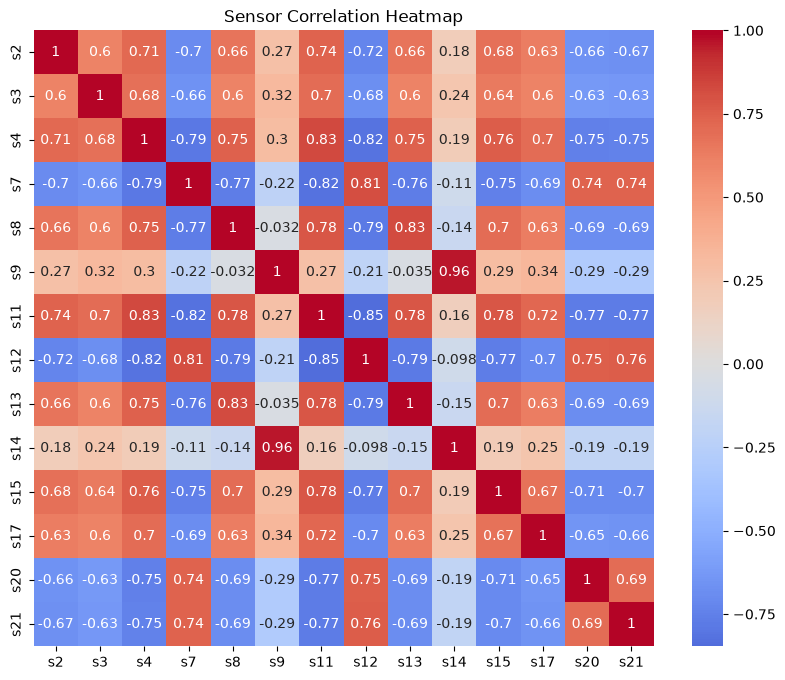

In [12]:
# Heatmap of sensor correlations to detect redundancy.
corr_matrix = df[high_variance_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Sensor Correlation Heatmap")
plt.show()

In [14]:
print(corr_matrix)

           s2        s3        s4        s7        s8        s9       s11  \
s2   1.000000  0.602610  0.714949 -0.702136  0.662325  0.273764  0.740020   
s3   0.602610  1.000000  0.678413 -0.664595  0.602481  0.322964  0.695900   
s4   0.714949  0.678413  1.000000 -0.793130  0.746852  0.297429  0.830136   
s7  -0.702136 -0.664595 -0.793130  1.000000 -0.767132 -0.217835 -0.822805   
s8   0.662325  0.602481  0.746852 -0.767132  1.000000 -0.032091  0.782213   
s9   0.273764  0.322964  0.297429 -0.217835 -0.032091  1.000000  0.274591   
s11  0.740020  0.695900  0.830136 -0.822805  0.782213  0.274591  1.000000   
s12 -0.724578 -0.680307 -0.815591  0.812713 -0.786540 -0.210238 -0.846884   
s13  0.661792  0.600963  0.745158 -0.764611  0.826084 -0.034763  0.780761   
s14  0.179752  0.237137  0.190748 -0.110053 -0.144787  0.963157  0.163408   
s15  0.675975  0.639921  0.758459 -0.747051  0.700949  0.293753  0.780913   
s17  0.629886  0.600017  0.703499 -0.692893  0.627785  0.337110  0.722296   